## AM115 Group Project - Solution Curves

## SEIRD Model
- states: Susceptible, Infected, Exposed, Dead, Recovered

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

The system of ODEs:
$$
\frac{dS}{dt} = - \frac{a(t)}{N} I S - c S + \gamma R
$$

$$
\frac{dE}{dt} = \frac{a(t)}{N} I S - \nu E
$$

$$
\frac{dI}{dt} = \nu E - b I - \eta I
$$

$$
\frac{dR}{dt} = b I + c S - \gamma R
$$

$$
\frac{dD}{dt} = \eta I
$$

Parameters:
$$
a(t) = pt \cdot nc(t)
$$
$$
nc(t) = 1 + 5 e^{-0.5  \max(t - 5, 0)}
$$
- $nc$ is a gradual lockdown

In [3]:
def nc_func(t, sharpness, min_val=1, max_val=6, lockdown_start=7):
    """
    Calculate contact rate nc with exponential decay after lockdown_start.

    Args:
        t: Current time
        sharpness: Negative value controlling decay speed (more negative = faster lockdown)
        min_val: Minimum contact rate (lockdown strength)
        max_val: Maximum contact rate (normal activity)
        lockdown_start: Fixed time when lockdown begins (default=5)

    Returns:
        Contact rate between min_val and max_val
    """
    t0 = max(t - lockdown_start, 0)  # Time since lockdown started
    decay = np.exp(sharpness * t0)  # Exponential decay factor
    return min_val + (max_val - min_val) * decay  # Always between min_val and max_val

In [4]:
def seird(t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=None):
    if lockdown:
        nc_val = nc_func(t, sharpness)
    else:
        nc_val = 6

    a = pt * nc_val
    s, e, i, r, d = X
    ds = -a * s * i / N - c * s + gamma * r
    de = a * s * i / N - nu * e
    di = nu * e - b * i - eta * i
    dr = b * i + c * s - gamma * r
    dd = eta * i
    return [ds, de, di, dr, dd]

In [5]:
# Parameters
# Time span for simulation is 120 days or
# roughly 4 months
tspan = (0, 120)
t_eval = np.arange(0, 120, 0.1)
# Population size
N = 2e6
# nc ranges from 6 to 1
# vary this to match the R0
pt = 0.1
# research found ranges from 0.03 to 0.06
b = 0.05
# The vacinnation rate from 2020-2021 was around 0.013
VAX_RATE = 0.69  # per year
c = VAX_RATE / (365)
# the death rate from infected was 0.008 but we round
DEATH_RATE = 0.01
eta = DEATH_RATE * b / (1 - DEATH_RATE)
gamma = 0.008
nu = 0.22
X0 = [int(N * 0.999), int(N * (1 - 0.999)), 0, 0, 0]
sharpness = -0.1  # Adjust this value to control lockdown sharpness

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=False, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T, X = sol.t, sol.y

# Solve ODE with 'Radau' or 'BDF' for stiff problems
sol_lock = solve_ivp(
    lambda t, X: seird(
        t, X, pt, b, c, eta, gamma, nu, N, lockdown=True, sharpness=sharpness
    ),
    tspan,
    X0,
    t_eval=t_eval,
    method="Radau",
)
# Unpack solution
T_lock, X_lock = sol_lock.t, sol_lock.y

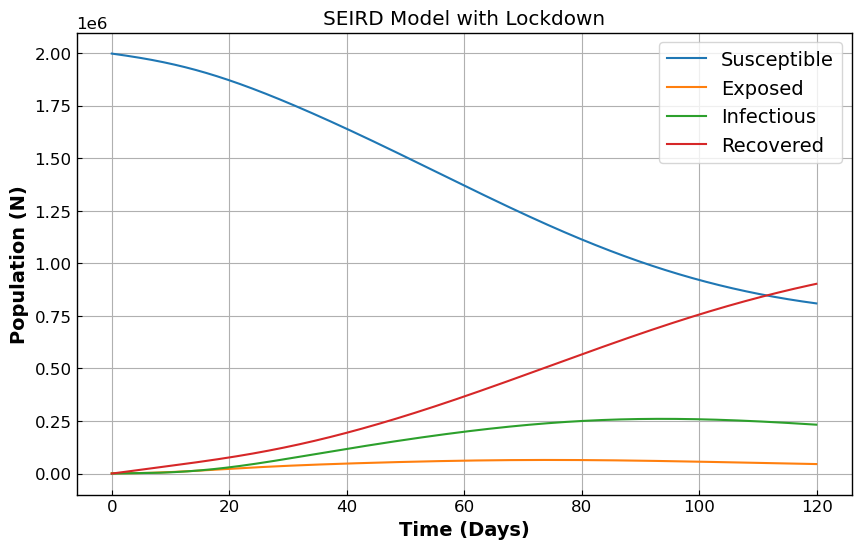

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T_lock, X_lock[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T_lock, X_lock[i], label=labels[i])

plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model with Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.savefig("./plots/solution_curve_lock.png")
plt.show()

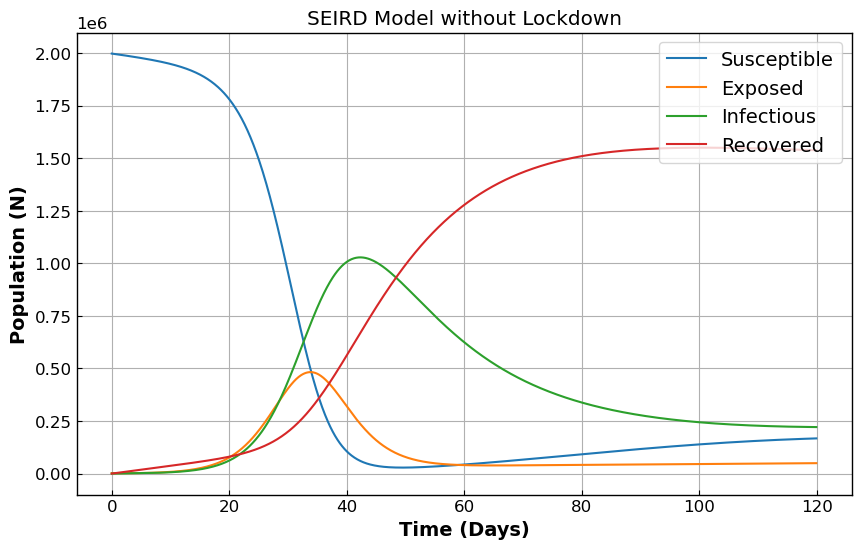

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ["Susceptible", "Exposed", "Infectious", "Recovered", "Cumulative Deceased"]
for i in range(4):

    if i == 4:
        plt.plot(T, X[i], label=labels[i], linestyle="--", color="black")
    else:
        plt.plot(T, X[i], label=labels[i])
plt.xlabel("Time (Days)")
plt.ylabel("Population (N)")
plt.title("SEIRD Model without Lockdown")
plt.legend(loc="upper right")
plt.grid(True)
plt.savefig("./plots/solution_curve_nolock.png")
plt.show()

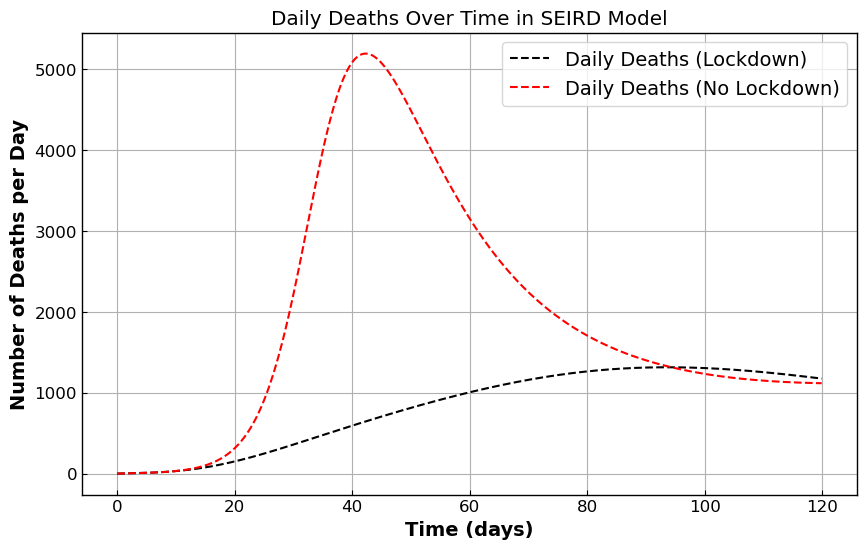

In [8]:
dt = t_eval[1] - t_eval[0]  # 0.1 days

daily_deaths = eta * X_lock[2] / dt
daily_deaths_no_lockdown = eta * X[2] / dt

plt.figure(figsize=(10, 6))
plt.plot(
    T_lock, daily_deaths, label="Daily Deaths (Lockdown)", color="black", linestyle="--"
)
plt.plot(
    T,
    daily_deaths_no_lockdown,
    label="Daily Deaths (No Lockdown)",
    color="red",
    linestyle="--",
)
plt.xlabel("Time (days)")
plt.ylabel("Number of Deaths per Day")
plt.title("Daily Deaths Over Time in SEIRD Model")
plt.legend()
plt.grid(True)
plt.savefig("./plots/daily_deaths.png")
plt.show()